In [10]:
import pathlib
from rescue import utils, models
from huggingface_hub import snapshot_download, notebook_login
import pathlib
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
notebook_login()

In [5]:
### Download sam3 model from huggingface ###
model_path = "../generated/sam3"
snapshot_download(repo_id="facebook/sam3", local_dir=model_path)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

'/edrive3/srohatgi/RESCUE/generated/sam3'

In [6]:
sam3_pred = models.sam3_predictor('../generated/sam3', device = 'cuda:4')

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

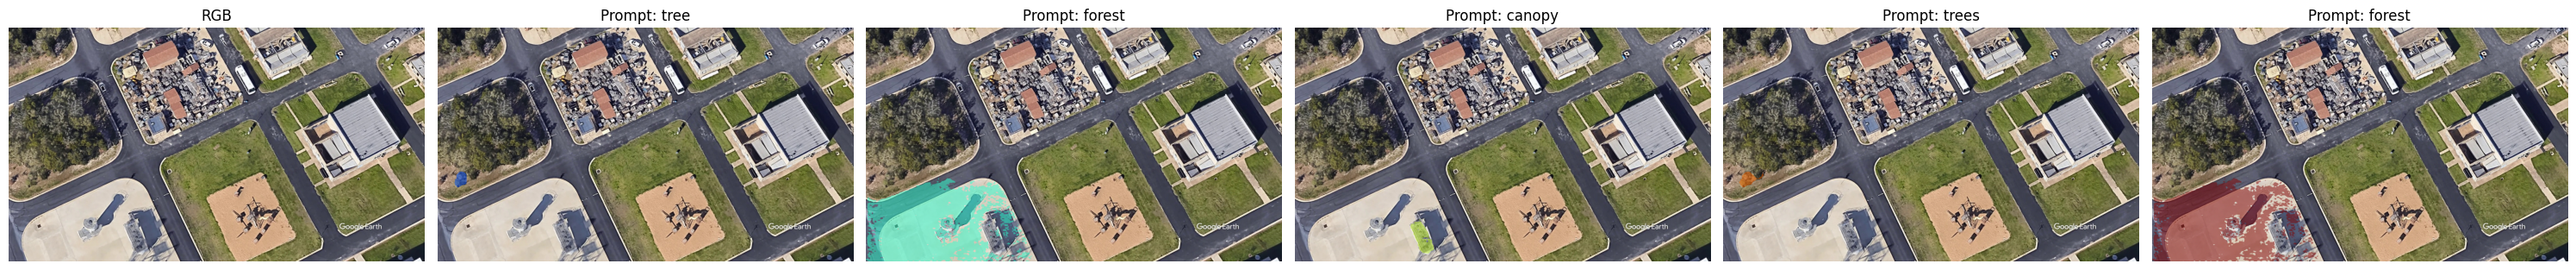

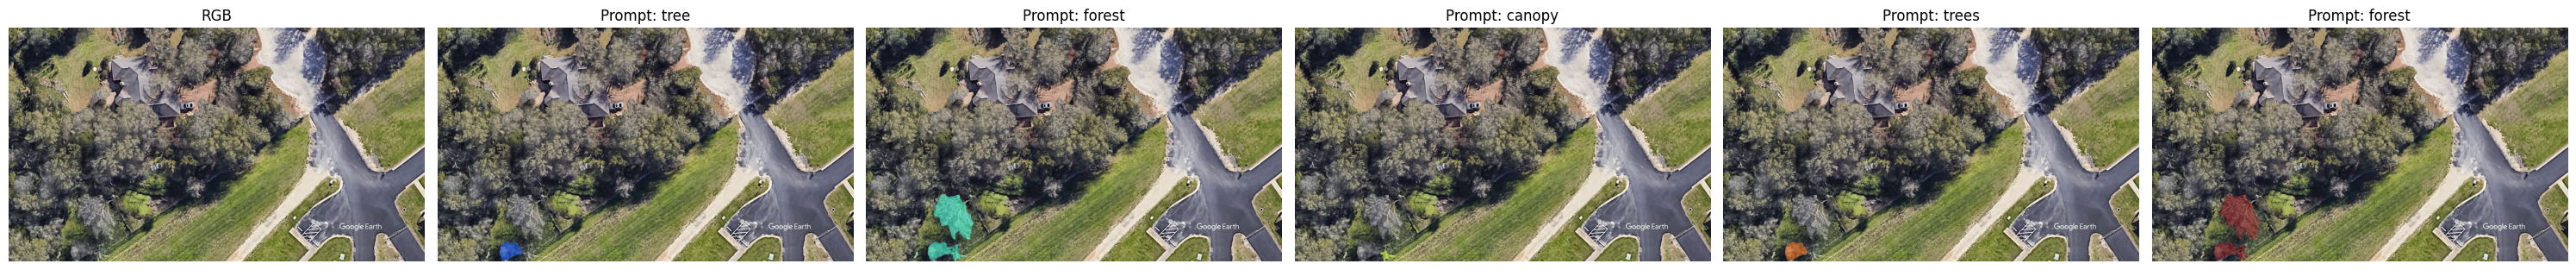

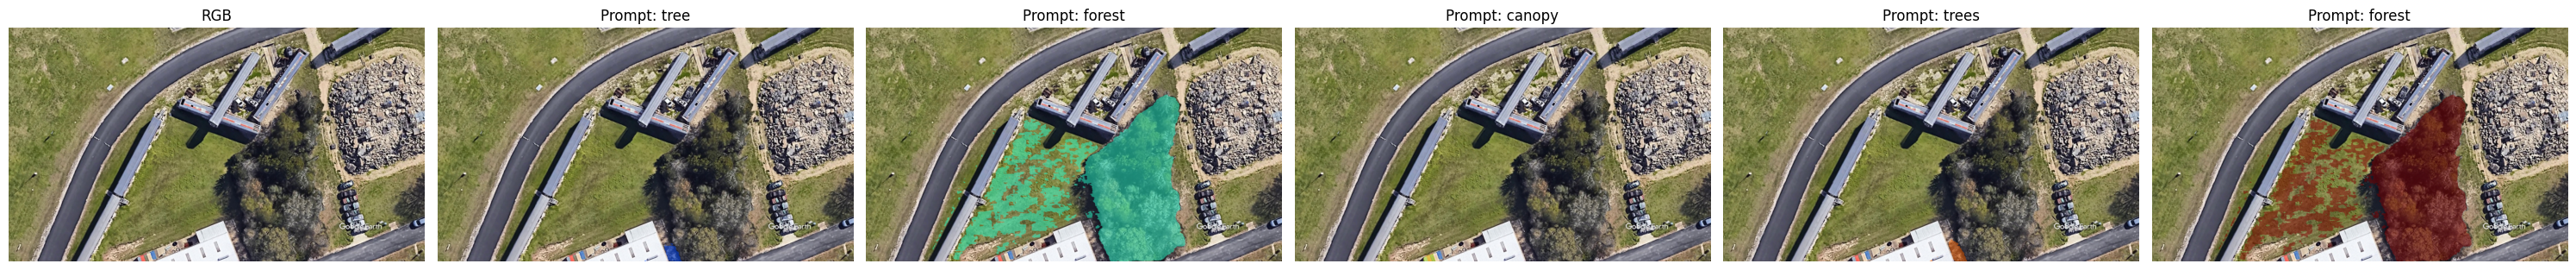

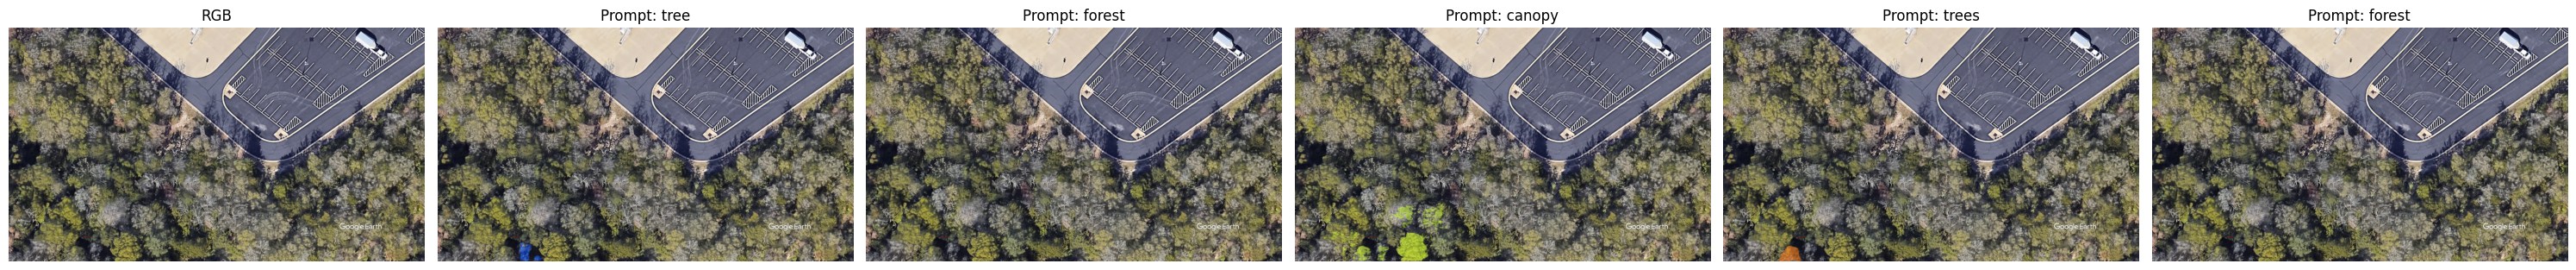

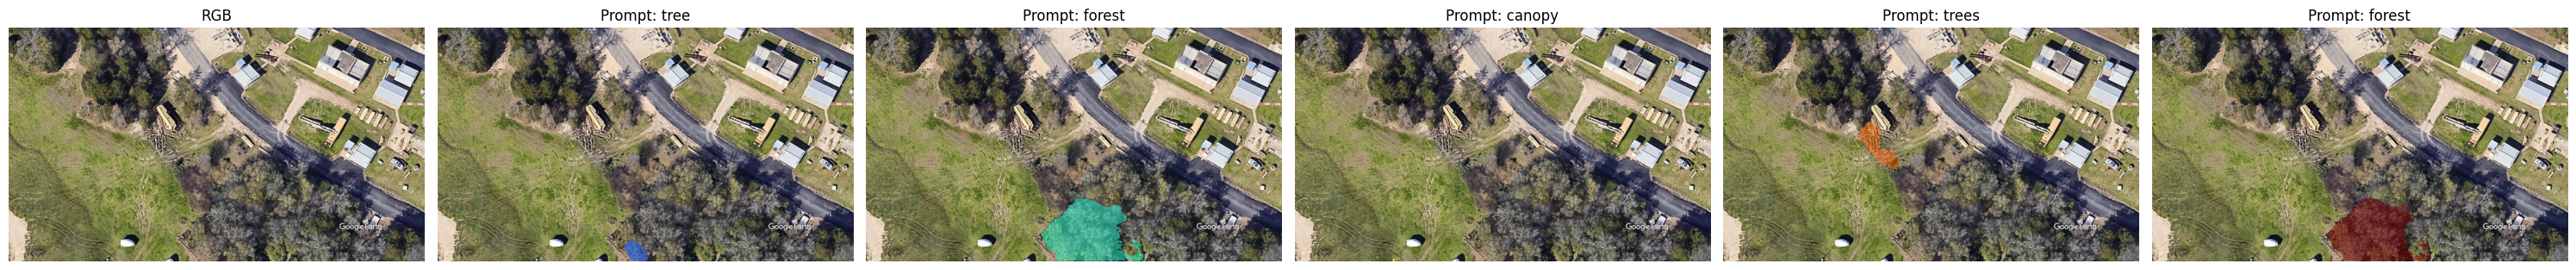

In [ ]:

num_imgs = 5
img_paths = list(pathlib.Path('../generated/sampled_disaster_city').glob('*.jpg'))
img_paths = np.random.permutation(img_paths)[:num_imgs]
keywords = ['']

for img_path in img_paths:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = sam3_pred.pred_on_prompts_and_single_img(img, keywords, threshold=0.3, mask_threshold=0.5)
    
    n_keywords = len(keywords)
    fig, axes = plt.subplots(1, n_keywords + 1, figsize=(5*(n_keywords+1), 5))
    
    # Show original image
    axes[0].imshow(img)
    axes[0].set_title('RGB')
    axes[0].axis('off')

    # Show mask results for each keyword with alpha blending
    for i, keyword in enumerate(keywords):
        # Get mask directly from list-of-dict output
        mask = None
        if isinstance(results, (list, tuple)) and len(results) == n_keywords:
            pred = results[i]
            if isinstance(pred, dict) and 'masks' in pred:
                masks_tensor = pred['masks']
                if hasattr(masks_tensor, "cpu"):
                    masks_np = masks_tensor.cpu().numpy()
                else:
                    masks_np = np.asarray(masks_tensor)
                if masks_np.ndim == 3 and masks_np.shape[0] > 0:
                    mask = masks_np[0]
                elif masks_np.ndim == 2:
                    mask = masks_np
        elif isinstance(results, dict):
            mask = results.get(keyword, None)
            if isinstance(mask, dict) and 'mask' in mask:
                mask = mask['mask']
        
        if mask is not None:
            mask = np.asarray(mask)
            # Normalize mask to 0-1 for blending, if necessary
            mask_float = mask.astype(np.float32)
            if mask_float.max() > 1.0:
                mask_float = mask_float / mask_float.max()
            # Create colored mask for blending: use a distinct color per keyword
            cmap = plt.get_cmap('jet')
            color_mask = cmap((i+1)/len(keywords))[:3]  # get a color in RGB, ignore alpha
            color_mask_array = np.array(color_mask).reshape(1,1,3)
            # Blend mask into image by replacing masked regions with color_mask
            alpha = 0.5
            img_norm = img.astype(np.float32) / 255.0
            color_mask_full = np.ones_like(img_norm) * color_mask_array  # broadcast color
            # Ensure mask has a channel axis
            if mask_float.ndim == 2:
                mask_float = mask_float[..., None]
            blended = img_norm * (1 - mask_float * alpha) + color_mask_full * (mask_float * alpha)
            blended = np.clip(blended, 0, 1)
            axes[i + 1].imshow(blended)
        else:
            axes[i + 1].imshow(img)
        axes[i + 1].set_title(f'Prompt: {keyword}')
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
